Original CatBoost Model


Categorical columns: ['Customer_ID', 'Gender', 'State', 'City', 'Bank_Branch', 'Account_Type', 'Transaction_ID', 'Merchant_ID', 'Transaction_Type', 'Merchant_Category', 'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Transaction_Currency', 'Transaction_Description']
Class ratio (0/1): 18.826517967781907
0:	test: 0.4952534	best: 0.4952534 (0)	total: 959ms	remaining: 7m 58s
50:	test: 0.5026392	best: 0.5070552 (22)	total: 43.2s	remaining: 6m 20s
100:	test: 0.5013125	best: 0.5070552 (22)	total: 1m 13s	remaining: 4m 50s
150:	test: 0.5050434	best: 0.5070552 (22)	total: 1m 48s	remaining: 4m 11s
200:	test: 0.5039484	best: 0.5070552 (22)	total: 2m 16s	remaining: 3m 22s
250:	test: 0.5016422	best: 0.5070552 (22)	total: 2m 56s	remaining: 2m 54s
300:	test: 0.5083175	best: 0.5083175 (300)	total: 3m 48s	remaining: 2m 31s
350:	test: 0.5065079	best: 0.5083175 (300)	total: 4m 44s	remaining: 2m
400:	test: 0.5112370	best: 0.5112370 (400)	total: 5m 43s	remaining: 1m 24s
450:	test: 0.5140475	b

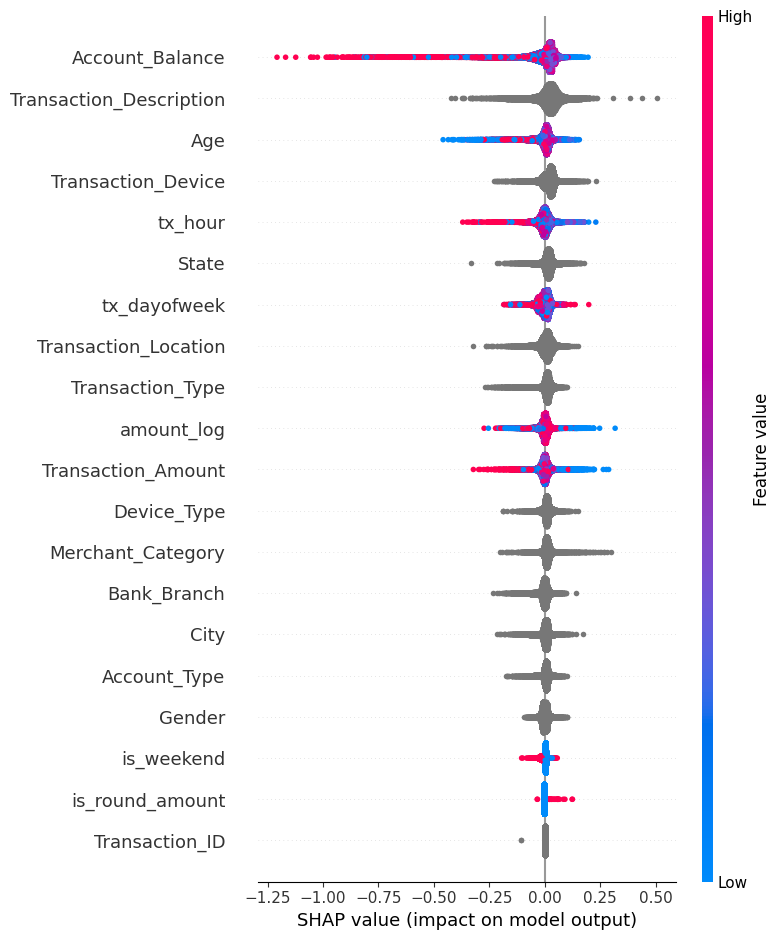

In [13]:
!pip install -q catboost shap

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from catboost import CatBoostClassifier
import shap
import matplotlib.pyplot as plt

# 1. Load data

df = pd.read_csv("Bank_Transaction_Fraud_Detection.csv")

# 2. Drop uneccessary column

drop_cols = [
    "Customer_Name",
    "Customer_Contact",
    "Customer_Email"
]
df = df.drop(columns=drop_cols)

# 3. Feature engineering

def add_features(df_):
    df = df_.copy()

    # datetime
    dt = pd.to_datetime(
        df["Transaction_Date"] + " " + df["Transaction_Time"],
        format="%d-%m-%Y %H:%M:%S"
    )
    df["tx_hour"] = dt.dt.hour
    df["tx_dayofweek"] = dt.dt.dayofweek
    df["tx_month"] = dt.dt.month
    df["is_weekend"] = (df["tx_dayofweek"] >= 5).astype(int)

    # amount features
    df["amount_log"] = np.log1p(df["Transaction_Amount"])
    df["is_round_amount"] = (
        ((df["Transaction_Amount"] % 10 == 0) |
         (df["Transaction_Amount"] % 100 == 0))
    ).astype(int)

    # drop raw date/time
    df = df.drop(columns=["Transaction_Date", "Transaction_Time"])
    return df

df = add_features(df)

# 4. Split

X = df.drop(columns=["Is_Fraud"])
y = df["Is_Fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 5. Categorical columns

cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns:", cat_cols)

cat_idx = [X_train.columns.get_loc(c) for c in cat_cols]


# 6. CatBoost with class weights

ratio = (y_train == 0).sum() / (y_train == 1).sum()
print("Class ratio (0/1):", ratio)

model = CatBoostClassifier(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=[1.0, ratio],
    random_state=42,
    verbose=50
)

model.fit(
    X_train, y_train,
    cat_features=cat_idx,
    eval_set=(X_test, y_test)
)

# 7. Evaluate

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))


# 8. SHAP – which features actually matter?

shap.initjs()
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test, show=True)


In [9]:
df.head(20)


,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_Amount,Transaction_Type,Merchant_Category,Account_Balance,...,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,tx_hour,tx_dayofweek,tx_month,is_weekend,amount_log,is_round_amount
0,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,32415.45,Transfer,Restaurant,74557.27,...,"Thiruvananthapuram, Kerala",POS,0,INR,16,3,1,0,10.386421,0
1,Female,51,Maharashtra,Nashik,Nashik Branch,Business,43622.60,Bill Payment,Restaurant,74622.66,...,"Nashik, Maharashtra",Desktop,0,INR,17,5,1,1,10.683354,0
2,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,63062.56,Bill Payment,Groceries,66817.99,...,"Bhagalpur, Bihar",Desktop,0,INR,3,5,1,1,11.051898,0
3,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,14000.72,Debit,Entertainment,58177.08,...,"Chennai, Tamil Nadu",Mobile,0,INR,12,6,1,1,9.546935,0
4,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,18335.16,Transfer,Entertainment,16108.56,...,"Amritsar, Punjab",Mobile,0,INR,18,3,1,0,9.816630,0
5,Male,54,Gujarat,Ahmedabad,Ahmedabad Branch,Checking,9711.15,Transfer,Entertainment,61258.85,...,"Ahmedabad, Gujarat",POS,0,INR,6,5,1,1,9.181133,0
6,Female,61,Delhi,New Delhi,New Delhi Branch,Business,94677.01,Transfer,Health,36313.61,...,"New Delhi, Delhi",Desktop,0,INR,0,5,1,1,11.458237,0
7,Male,32,Andaman and Nicobar Islands,Port Blair,Port Blair Branch,Business,67704.28,Debit,Clothing,16948.73,...,"Port Blair, Andaman and Nicobar Islands",ATM,0,INR,4,3,1,0,11.122919,0
8,Male,52,Madhya Pradesh,Bhopal,Bhopal Branch,Business,72953.45,Withdrawal,Clothing,18138.71,...,"Bhopal, Madhya Pradesh",Mobile,0,INR,10,5,1,1,11.197591,0
9,Female,32,Chhattisgarh,Jagdalpur,Jagdalpur Branch,Business,5689.02,Credit,Entertainment,65801.35,...,"Jagdalpur, Chhattisgarh",Desktop,0,INR,4,3,1,0,8.646469,0


In [6]:
df.corr(numeric_only=True)["Is_Fraud"].sort_values(ascending=False)


,Is_Fraud
Is_Fraud,1.000000
is_round_amount,0.001584
Account_Balance,0.000125
Age,-0.001517
tx_hour,-0.001960
Transaction_Amount,-0.002100
tx_dayofweek,-0.002582
is_weekend,-0.003783
amount_log,-0.008023
tx_month,NaN


In [7]:
df.groupby("Transaction_Type")["Is_Fraud"].mean()
df.groupby("Merchant_Category")["Is_Fraud"].mean()
df.groupby("Device_Type")["Is_Fraud"].mean()
df.groupby("Transaction_Device")["Is_Fraud"].mean()
df.groupby("State")["Is_Fraud"].mean()


,Is_Fraud
State,
Andaman and Nicobar Islands,0.047497
Andhra Pradesh,0.048155
Arunachal Pradesh,0.048657
Assam,0.049862
Bihar,0.046611
Chandigarh,0.049681
Chhattisgarh,0.049158
Dadra and Nagar Haveli and Daman and Diu,0.052074
Delhi,0.050984


In [8]:
df["Is_Fraud"].value_counts(normalize=True)


,proportion
Is_Fraud,
0,0.94956
1,0.05044


In [10]:
df.groupby("Merchant_Category")["Is_Fraud"].mean().sort_values()


,Is_Fraud
Merchant_Category,
Entertainment,0.048233
Health,0.049852
Electronics,0.050316
Restaurant,0.050350
Groceries,0.051888
Clothing,0.052010


With Added Columns

Categorical columns: ['Customer_ID', 'Gender', 'State', 'City', 'Bank_Branch', 'Account_Type', 'Transaction_ID', 'Merchant_ID', 'Transaction_Type', 'Merchant_Category', 'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Transaction_Currency', 'Transaction_Description', 'hour_bin', 'hourbin_highvalue', 'txtype_night']
Class ratio (0/1): 18.826517967781907
0:	test: 0.5088838	best: 0.5088838 (0)	total: 793ms	remaining: 6m 35s
50:	test: 0.5031325	best: 0.5090283 (1)	total: 47.1s	remaining: 6m 54s
100:	test: 0.5011120	best: 0.5090283 (1)	total: 1m 34s	remaining: 6m 14s
150:	test: 0.5005460	best: 0.5090283 (1)	total: 2m 20s	remaining: 5m 24s
200:	test: 0.5015508	best: 0.5090283 (1)	total: 3m 3s	remaining: 4m 32s
250:	test: 0.4985861	best: 0.5090283 (1)	total: 3m 56s	remaining: 3m 54s
300:	test: 0.4906419	best: 0.5090283 (1)	total: 5m 8s	remaining: 3m 24s
350:	test: 0.4891778	best: 0.5090283 (1)	total: 6m 14s	remaining: 2m 39s
400:	test: 0.4895627	best: 0.5090283 (1)	total: 7m 19s	

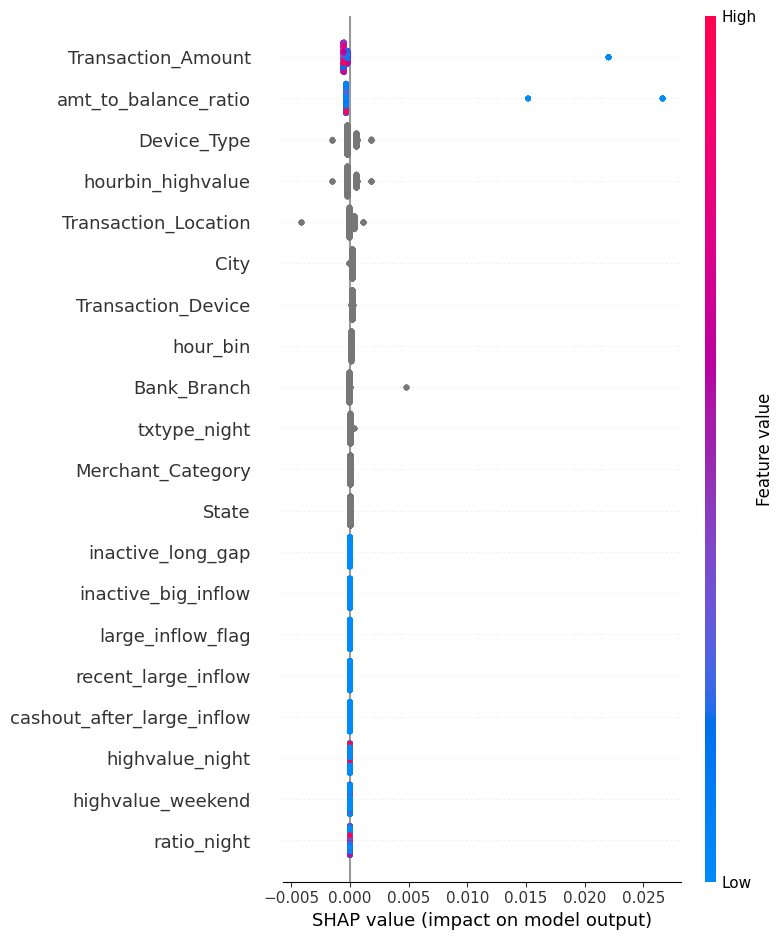

In [9]:
# 0. Imports
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

from catboost import CatBoostClassifier
import shap
import matplotlib.pyplot as plt

# 1. Load data & drop PII

df = pd.read_csv("Bank_Transaction_Fraud_Detection.csv")

df = df.drop(columns=[
    "Customer_Name",
    "Customer_Contact",
    "Customer_Email"
])

# 2. Feature engineering

def add_features(df_):
    df = df_.copy()

    # 2.1 Base datetime features

    dt = pd.to_datetime(
        df["Transaction_Date"] + " " + df["Transaction_Time"],
        format="%d-%m-%Y %H:%M:%S"
    )
    df["tx_datetime"]   = dt
    df["tx_hour"]       = dt.dt.hour
    df["tx_dayofweek"]  = dt.dt.dayofweek
    df["tx_month"]      = dt.dt.month
    df["is_weekend"]    = (df["tx_dayofweek"] >= 5).astype(int)
    df["is_night"]      = ((df["tx_hour"] < 6) | (df["tx_hour"] >= 22)).astype(int)

    # Hour bin (categorical)
    df["hour_bin"] = pd.cut(
        df["tx_hour"],
        bins=[-1, 6, 12, 18, 24],
        labels=["Night", "Morning", "Afternoon", "Evening"]
    ).astype("object")

    # 2.2 Amount features

    df["amount_log"] = np.log1p(df["Transaction_Amount"])
    df["is_round_amount"] = (
        ((df["Transaction_Amount"] % 10 == 0) |
         (df["Transaction_Amount"] % 100 == 0))
    ).astype(int)

    global_median = df["Transaction_Amount"].median()
    df["is_high_value"] = (df["Transaction_Amount"] > global_median).astype(int)

    df["amt_to_balance_ratio"] = df["Transaction_Amount"] / (df["Account_Balance"] + 1e-6)

    # 2.3 Inflow / outflow flags (approximation)

    inflow_types  = ["Credit"]
    outflow_types = ["Debit", "Withdrawal", "Transfer", "Bill Payment"]

    df["is_inflow"]  = df["Transaction_Type"].isin(inflow_types).astype(int)
    df["is_outflow"] = df["Transaction_Type"].isin(outflow_types).astype(int)

    # 2.4 Customer-level time gaps (inactivity)
    # Sort by customer + time
    df = df.sort_values(["Customer_ID", "tx_datetime"])

    # Previous transaction time per customer
    df["prev_tx_time"] = df.groupby("Customer_ID")["tx_datetime"].shift(1)

    # Days since previous transaction
    df["days_since_prev_tx"] = (
        (df["tx_datetime"] - df["prev_tx_time"]).dt.total_seconds() / 86400
    )

    # For first transaction of a customer, fill with global median gap
    median_gap = df["days_since_prev_tx"].median()
    df["days_since_prev_tx"] = df["days_since_prev_tx"].fillna(median_gap)

    # Inactivity flag (e.g. > 7 days)
    df["inactive_long_gap"] = (df["days_since_prev_tx"] > 7).astype(int)

    # Interaction: inactive for long + big inflow
    df["inactive_big_inflow"] = (
        df["inactive_long_gap"] * df["is_inflow"] * df["is_high_value"]
    )


    # 2.5 Large inflow then quick cash-out pattern

    large_inflow_thresh = df["Transaction_Amount"].quantile(0.99)
    df["large_inflow_flag"] = (
        (df["is_inflow"] == 1) & (df["Transaction_Amount"] >= large_inflow_thresh)
    ).astype(int)

    # For each customer, check if there was a large inflow in last K txns
    K = 3  # last 3 transactions as "recent"

    def recent_large_inflow(series):
        # shift by 1 to avoid counting the current transaction itself
        return series.shift(1).rolling(window=K, min_periods=1).max()

    df["recent_large_inflow"] = (
        df.groupby("Customer_ID")["large_inflow_flag"]
          .apply(recent_large_inflow)
          .reset_index(level=0, drop=True)
          .fillna(0)
    )

    # Cash-out after recent large inflow
    df["cashout_after_large_inflow"] = (
        (df["recent_large_inflow"] == 1) & (df["is_outflow"] == 1)
    ).astype(int)


    # 2.6 Other interaction features

    df["highvalue_night"]   = df["is_high_value"] * df["is_night"]
    df["highvalue_weekend"] = df["is_high_value"] * df["is_weekend"]
    df["ratio_night"]       = df["amt_to_balance_ratio"] * df["is_night"]

    df["is_business_acct"]  = (df["Account_Type"] == "Business").astype(int)
    df["busacct_highvalue"] = df["is_business_acct"] * df["is_high_value"]

    df["hourbin_highvalue"] = df["hour_bin"].astype(str) + "_" + df["is_high_value"].astype(str)
    df["txtype_night"]      = df["Transaction_Type"].astype(str) + "_" + df["is_night"].astype(str)


    # 2.7 Clean up
    df = df.drop(columns=["Transaction_Date", "Transaction_Time", "prev_tx_time"])

    return df

# apply feature engineering
df = add_features(df)


# 3. Train/test split

X = df.drop(columns=["Is_Fraud"])
y = df["Is_Fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 4. Categorical columns

cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
cat_idx  = [X_train.columns.get_loc(c) for c in cat_cols]

print("Categorical columns:", cat_cols)


# 5. CatBoost model (no early stopping)

ratio = (y_train == 0).sum() / (y_train == 1).sum()
print("Class ratio (0/1):", ratio)

model = CatBoostClassifier(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=[1.0, ratio],
    random_state=42,
    verbose=50
)

model.fit(
    X_train, y_train,
    cat_features=cat_idx,
    eval_set=(X_test, y_test)
)

# 6. Evaluate

y_proba = model.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))


# 7. SHAP (sampled)

shap.initjs()

X_shap = X_test.sample(min(1500, len(X_test)), random_state=42)

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap)
